In [1]:
import sys, os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.join('..', 'src'))
sns.set_theme(style='ticks', context='notebook')
warnings.filterwarnings("error", category=FutureWarning)
warnings.filterwarnings("error", category=RuntimeWarning)
pd.set_option('mode.chained_assignment', 'raise')

# Analisis de datos

## Curado de features

In [59]:
df = pd.read_csv('../data/raw/casas_dev.csv')
PROCESSED_DATA_PATH = '../data/processed/'

from utils import getRandomSample, countUniqueData
from preprocessing import preprocessingData

In [3]:
getRandomSample(df, n=10)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
0,65593.926790,casa,211.934700,133.698774,m2,10,3.0,True,-34.776990,-58.194234,40.358607
1,20449.828587,casa,203.244733,148.448182,m2,10,3.0,False,-34.725878,-58.263450,1.000000
2,3490.465335,casa,233.556843,108.433864,m2,4,1.0,False,-34.857743,-58.277317,1.000000
3,188443.738433,depto,769.075301,766.505187,sqft,7,NaN,False,40.698582,-74.025030,12.079080
4,141276.510804,depto,632.939668,607.747477,sqft,5,NaN,False,40.697600,-74.008722,1.904031
5,2930.895844,depto,76.968500,76.461160,m2,4,NaN,False,-34.708707,-58.255102,8.353618
6,33242.492587,casa,213.185377,114.482322,m2,8,3.0,False,-34.750840,-58.197258,63.950958
7,117557.887320,depto,783.859454,752.142557,sqft,1,NaN,False,40.664963,-74.014036,NaN
8,16432.200442,casa,243.695159,130.360398,m2,3,1.0,True,-34.672900,-58.239475,25.796261
9,129770.110769,depto,704.392847,689.829662,sqft,4,NaN,False,40.708035,-74.033047,7.881549


Primero vemos la columna "tipo" y "unidades" buscando inconsistencias gramaticales o caracteristicas que se repitan muy poco.

In [4]:
countUniqueData(df, 'tipo')
countUniqueData(df, 'unidades')

Datos de la columna 'tipo':
 - depto: 852
 - casa: 662
 - ph: 86
Datos de la columna 'unidades':
 - sqft: 693
 - m2: 907


Arreglamos los datos y contamos cuantos de estos faltan (NaNs) siguiendo las siguientes reglas:

- precio: es nuestro label para el modelo, verificamos que todos los datos sean de tipo float y eliminamos las filas con NaNs.
- tipo: notamos 3 distintos tipos, aca no tocaremos nada ya que los datos estan sanos y hay buena frecuencia en ellos. Hace un poco de ruido ver que ph tiene menos apariciones pero para solucionarlo se plantea estratificar a la hora de hacer los splits.
- area: por comodidad decidi normalizar el encabezado a 'area'. Aqui solamente buscaremos que todos los datos sean floats y positivos.
- metros cubiertos: seguimos la misma idea que area, floats positivos unicamente.
- unidades: Esta columna se eliminara y todas las filas que tienen sqft seran modificadas para que area y metros cubiertos esten en metros cuadrados. De esta forma se vuelve un feature redundante.
- ambientes: buscamos que todos los datos sean ints positivos. Idem pisos.
- pileta: mantendremos bool y chequeamos que todos los datos esten correctos.
- Tanto lat, lon y edad, a priori, solo revisaremos que esten completos con floats.

In [5]:
df = preprocessingData(df)

Filas con area invalida: 0
Filas con metros cubiertos invalidos: 0
Filas con ambientes invalidos: 0
Filas con pisos invalidos: 799
Filas con pileta invalida: 0
Filas con latitud invalida: 0
Filas con longitud invalida: 0
Filas con edad invalida: 138


### Imputo de datos

Como pudimos ver en los resultados del curado, la mayoria de las filas estas sanas. En cuanto a los pisos de las propiedades, notamos que hay mas de un 50% de los datos faltantes por lo que la mejor desicion en este caso seria eliminar la columna directamente. Sin embargo, en este caso en especifico, si contamos la nos ponemos a buscar un motivo por el cual pueden estar faltando los pisos, nos daremos cuenta de que los datos faltantes no son aleatorios, en realidad son los deptos los unicos que no tienen este valor asignado. Para no descartar la columna que tanto para casas como para ph puede resultar importante, vamos a asumir el caso mas comun que es que el departamento cuente con un unico piso.

In [6]:
df['pisos'] = df['pisos'].fillna(1).astype(int)

La antigüedad de la casa, al tener un porcentaje menor de datos incompletos podemos imputarla usando la mediana simplemente. Con esto nos ahorramos eliminar muchas filas por falta de datos al usar un valor normal para remplazar los faltantes. Usamos la mediana para que no nos sesguen los outliers

In [ ]:
df['edad'] = df['edad'].fillna(df['edad'].median())
df.to_csv(PROCESSED_DATA_PATH + 'casas_dev.csv', index=False)

### Dataset procesado

In [8]:
getRandomSample(df, n=10)

,precio,tipo,area,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
0,14064.407364,casa,212.408778,108.007444,7,3,False,-34.813843,-58.258523,1.000000
1,31877.599463,casa,206.438745,140.260386,8,3,True,-34.792506,-58.276698,67.165515
2,163126.558604,depto,68.199411,68.084547,4,1,False,40.696966,-74.016213,12.136982
3,26228.482449,casa,237.932104,150.104435,10,3,False,-34.675976,-58.270023,47.463112
4,34655.868742,casa,199.838751,158.712120,10,3,True,-34.698801,-58.248066,56.401715
5,37256.957916,casa,242.477434,134.342263,10,3,True,-34.787223,-58.160211,13.061086
6,137613.423879,depto,65.173299,64.037706,7,1,False,40.706608,-73.972500,1.777350
7,30011.098053,casa,230.885296,166.324013,10,3,False,-34.776030,-58.241117,29.268925
8,18896.517642,depto,64.723652,64.244788,9,1,False,-34.774109,-58.210881,14.717690
9,23437.449764,casa,170.344959,92.859809,9,3,True,-34.725844,-58.256431,1.000000


## Graficos

In [9]:
TYPES_PALETTE = {
    'casa': "#1D56B1",
    'depto': "#AD2424",
    'ph': "#2B6C3A"
}

LABELS = {
    'precio': 'Precio (USD)',
    'tipo': 'Tipo de Propiedad',
    'area': 'Área Total (m2)',
    'metros_cubiertos': 'Metros Cubiertos (m2)',
    'ambientes': 'Ambientes',
    'pisos': 'Pisos',
    'pileta':'Pileta',
    'lat': 'Latitud (°)',
    'lon': 'Longitud (°)',
    'edad': 'Antigüedad (años)',
    'region': 'Región',
    'log_precio': 'Precio Aplicando log (USD)'
}

### Histogramas

Primero nos interesa contabilizar la cantidad de apariciones que tienen distintos rangos de cada feature. Con esto podemos empezar a trazar distribuciones que nos ayudan para entender la naturaleza de nuestros datos.

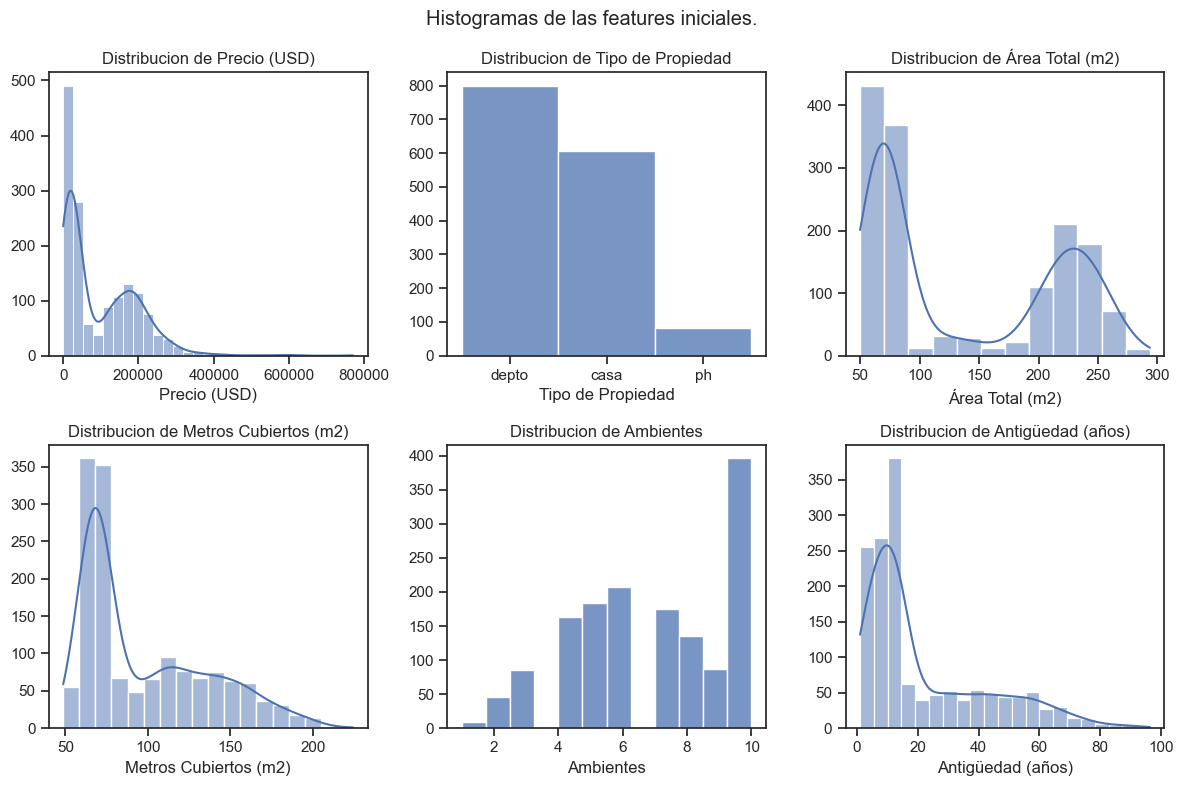

In [10]:
_, axes = plt.subplots(2, 3, figsize=(12,8))

features = [f for f in df.columns if f not in ['pisos', 'pileta', 'lat', 'lon']]
for feature, ax in zip(features, axes.flatten()):
    sns.histplot(
        data=df,
        x=feature,
        kde=True if feature not in ['tipo', 'ambientes'] else False,
        ax=ax
    )
    ax.set_title(f'Distribucion de {LABELS[feature]}')
    ax.set_xlabel(LABELS[feature])
    ax.set_ylabel('')

plt.suptitle("Histogramas de las features iniciales.")
plt.tight_layout()
plt.show()

A primera vista los graficos no nos dicen mucho, a priori, podemos notar la diferencia de frecuencia que tienen los ph respecto a las otras dos variantes de propiedades que notamos anteriormente. 
Ademas vemos que el precio parece tener una distribucion cercana a la normal con una gran presencia de outliers cerca del 0.
Algo que sorprende, es la alta cantidad de propiedades con 10 ambientes que encontramos, similarmente al precio vemos que del 1 al 9 encontramos una colina y luego en el 10 un pico muy alto respecto al resto.

### Scatterplots

Ahora buscamos enfrentar las columnas entre si con la ayuda de scatterplots, buscamos relaciones entre nuestros datos para ver por donde conviene encarar el armado del modelo. Aqui es cuando se comienzan a identificar cuales son las features mas importantes.

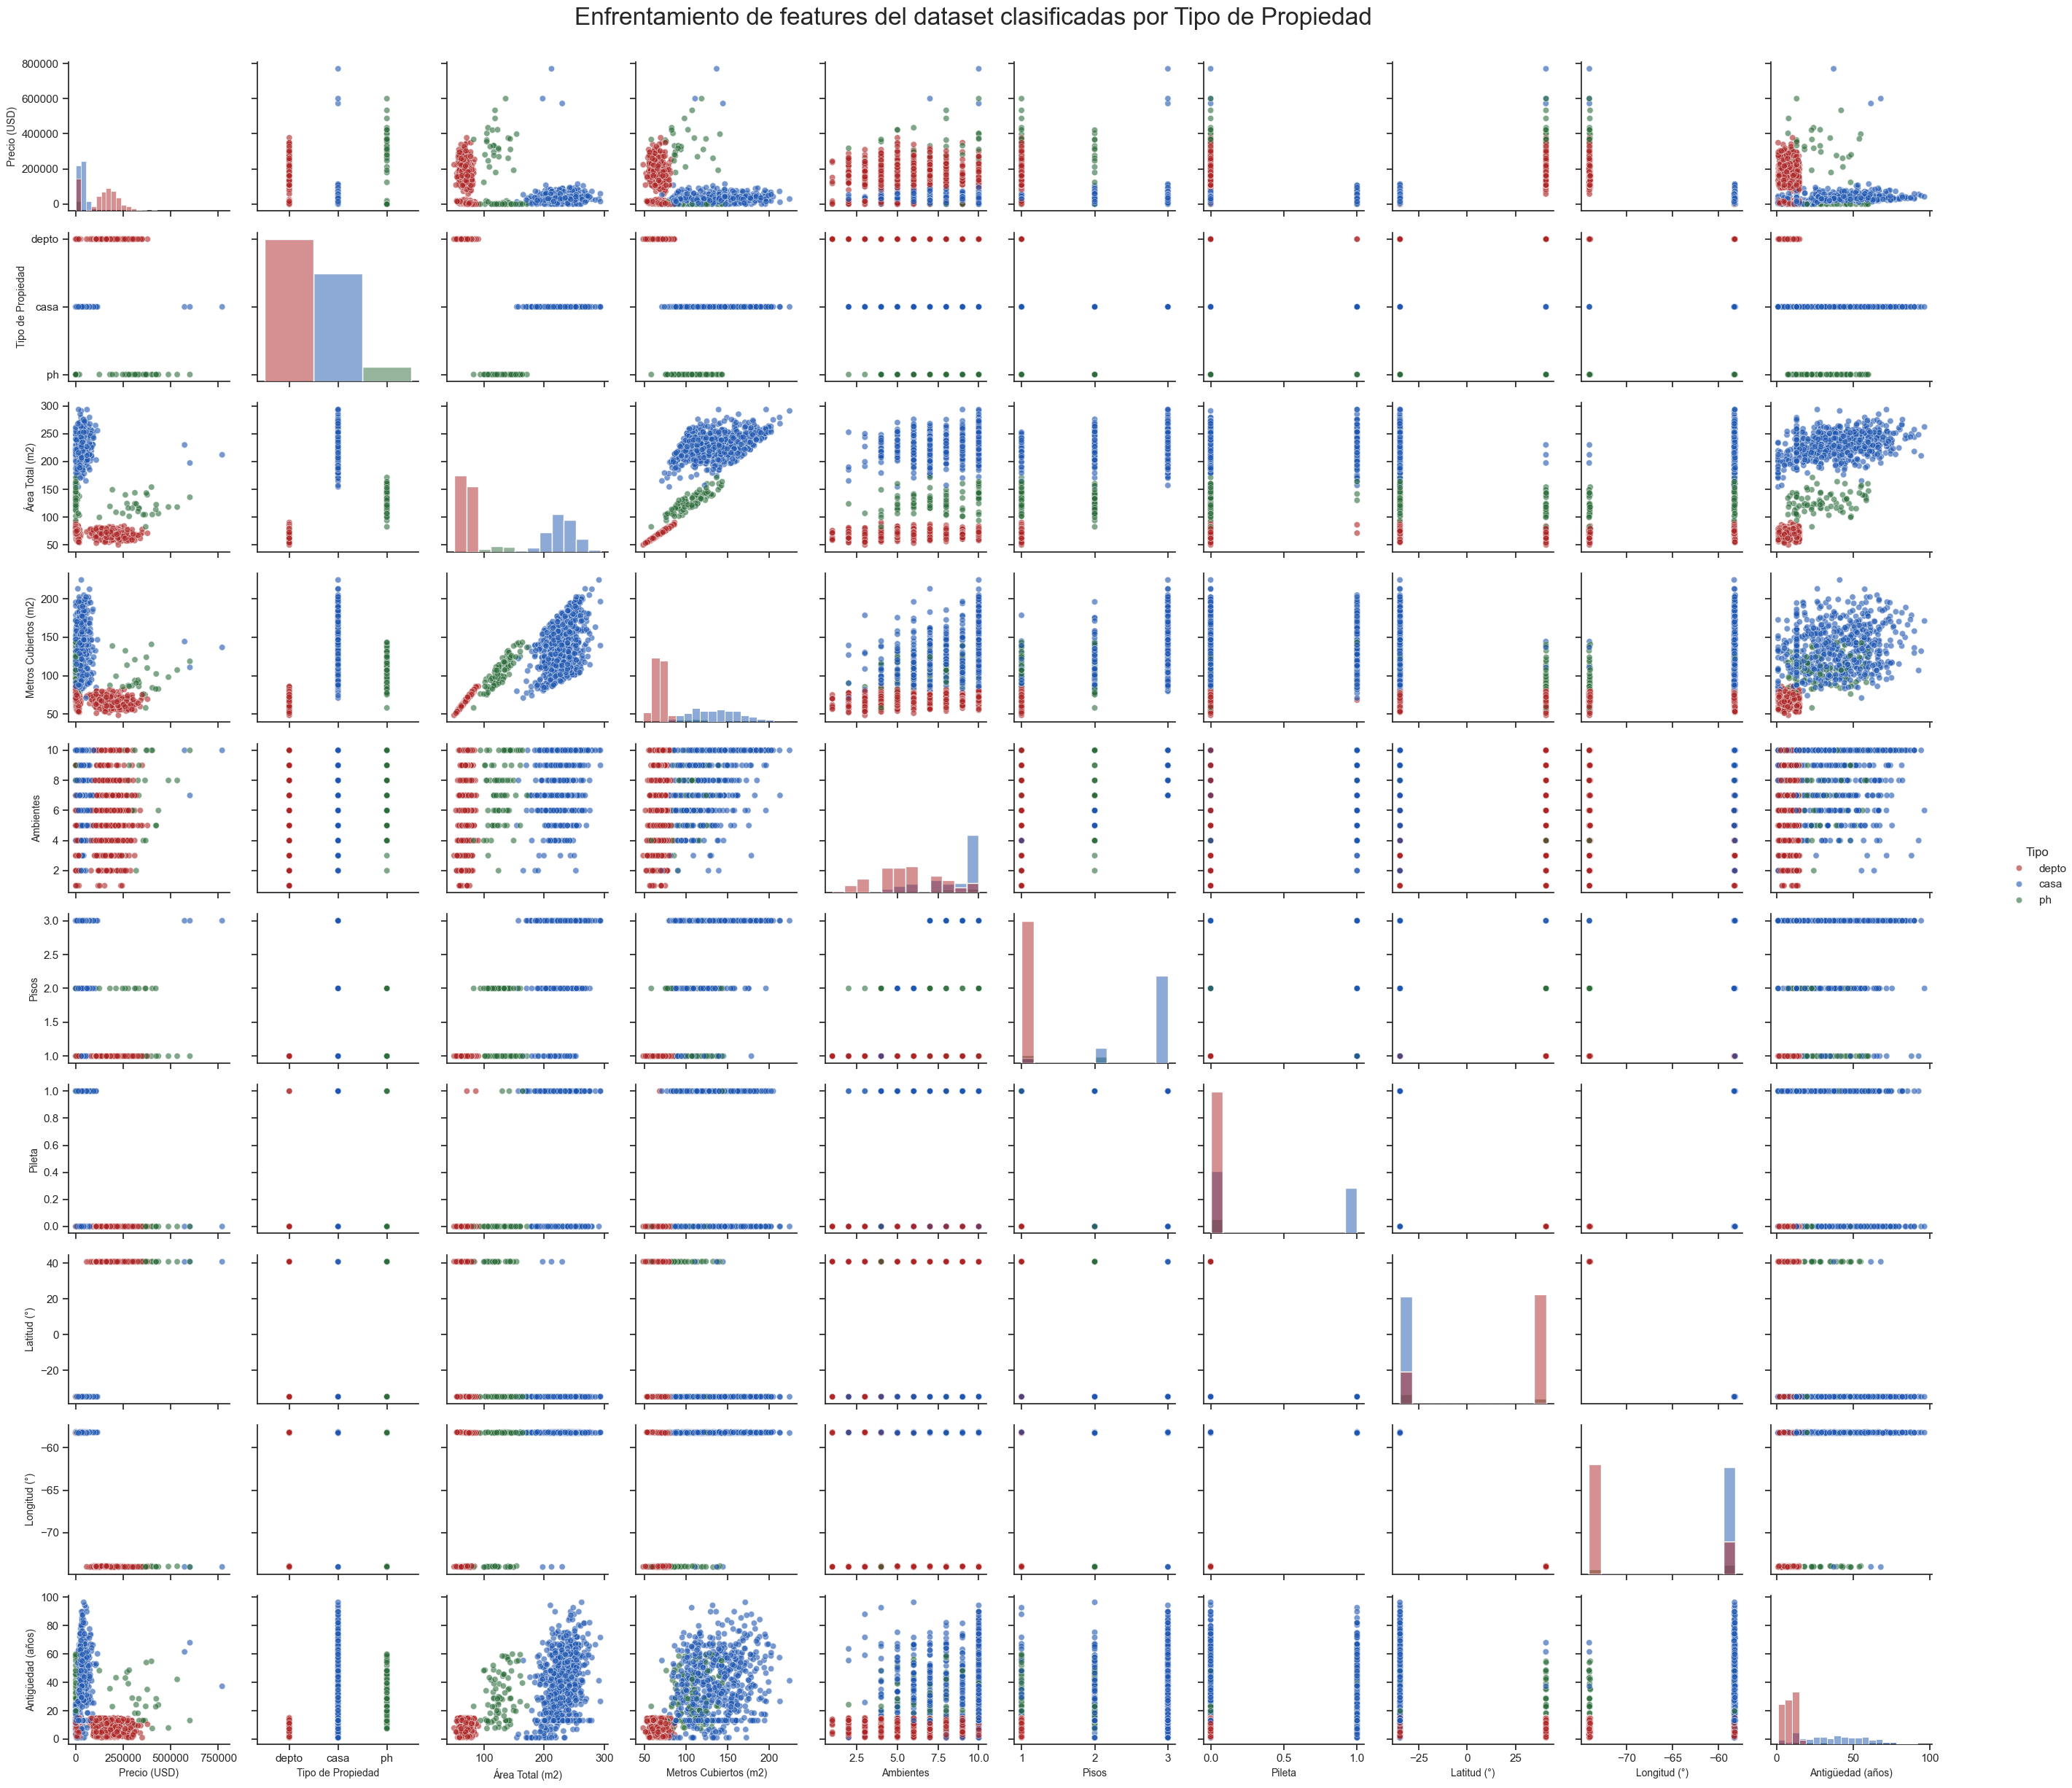

In [11]:
features = df.columns
g = sns.pairplot(
    df,
    vars=features[:10],
    hue='tipo',
    palette=TYPES_PALETTE,
    kind='scatter',
    diag_kind='hist',
    plot_kws={'alpha': 0.6},
)

g._legend.remove()
g.add_legend(title="Tipo")
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_loc("center left")
g.figure.subplots_adjust(right=0.85)

for i, y_var in enumerate(g.y_vars):
    for j, x_var in enumerate(g.x_vars):
        ax = g.axes[i, j]

        if i == len(g.y_vars) - 1:
            ax.set_xlabel(LABELS[x_var], fontsize=10)

        if j == 0:
            ax.set_ylabel(LABELS[y_var], fontsize=10)

g.figure.suptitle(f'Enfrentamiento de features del dataset clasificadas por {LABELS['tipo']}', fontsize=24)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.95)

Lo primero que salta a la vista es ver que en general las casas parecen ser la propiedad mas barata de todas, siendo superada por algunos ph y la mayor parte de los departamentos. Ademas son estas las que mas presencia tienen en ese pico cercano al 0 que notamos en el histograma del precio.
Luego, contraintuitivamente, notamos que el area o metros cubiertos no parece ser quienes dicten realmente el precio. A pesar de que en principio me esperaba ver un intento de relacion lineal entre estas variables. Los datos no estarian apoyando mi hipotesis siendo que, los departamentos, los que menos area ocupan, son los que tienden a mostrar un precio superior.

Por ultimo, hay otro detalle que se hace notar rapido y es la distribucion geografica de los datos, el enfrentamiento de Latitud vs Longitud muestran dos clusters clarisimos que parecen mostrar que estamos hablando de dos zonas totalmente distintas y muy separadas que analizaremos mas adelante.

### Boxplots

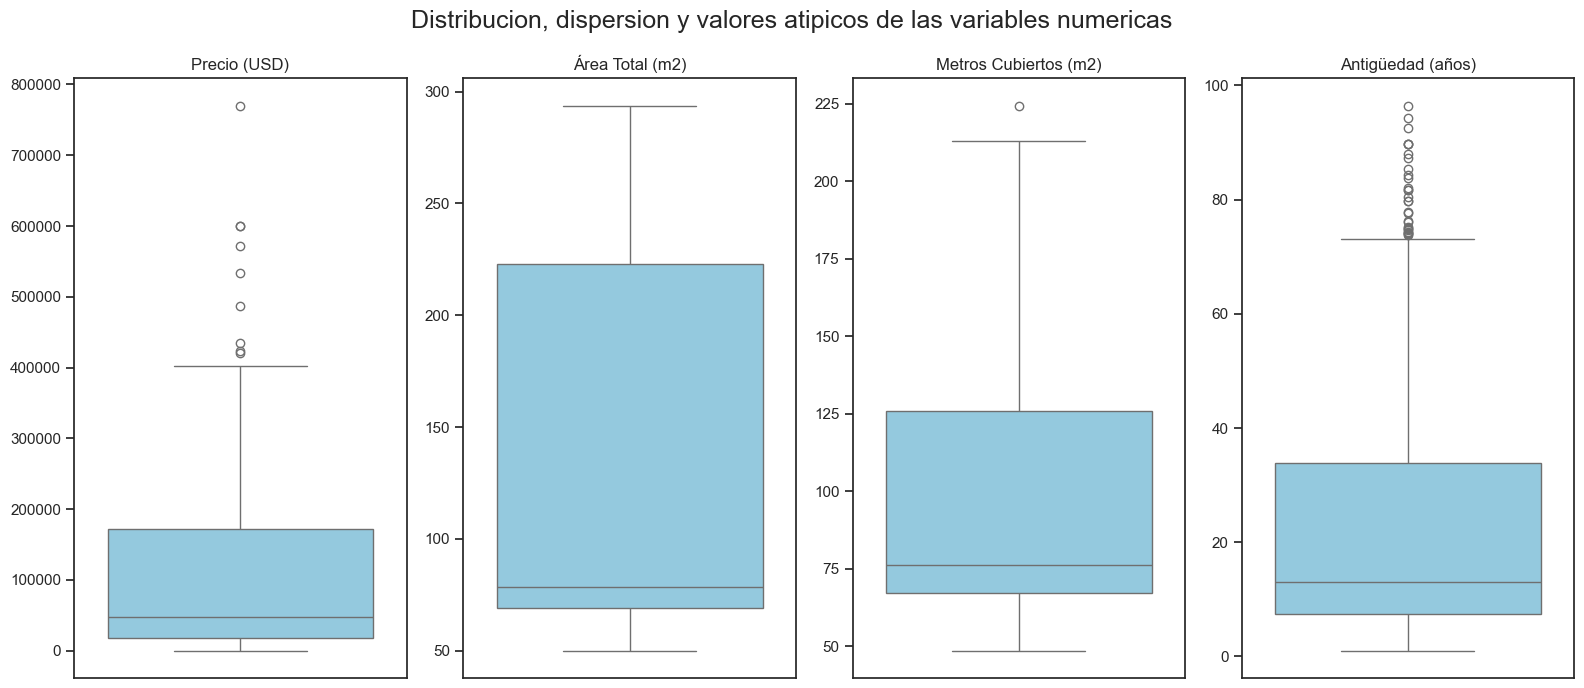

In [12]:
_, axes = plt.subplots(1, 4, figsize=(16, 7))

features = [f for f in df.columns if f not in ['tipo', 'ambientes', 'pisos', 'pileta', 'lat', 'lon']]
for feature, ax in zip(features, axes.flatten()):
    sns.boxplot(
        y=df[feature],
        ax=ax,
        color='skyblue'
    )
    ax.set_title(LABELS[feature])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])

plt.suptitle('Distribucion, dispersion y valores atipicos de las variables numericas', fontsize=18)
plt.tight_layout()
plt.show()

## Organizacion de los datos

In [ ]:
from data_splitting import splitData
from preprocessing import normalizeData

### Division de folds

Para un mejor uso de los datos a la hora de entrenar nuetro modelo, vamos a separar en dos nuestro set de entrenamiento. Un 80% ira para train y un 20% para validation.

Luego, vamos a manipular los datos para escalar, normalizar o encodear cada feature segun como corresponda dependiendo de si son continuas, categoricas, etc. Esto nos va a ayudar a hacer mas estable el aprendizaje de nuestro modelo facilitando la convergencia en gran medida.

In [ ]:
train, valid = splitData(df, stratify='tipo')

### Normalizacion y encoding

Vamos a comenzar a normalizar los datos como mejor nos convenga segun lo que pudimos analizar en los graficos, inicialmente comenzaremos con este planning "teorico" para una primera aproximacion en estos primeros modelos simples. Mas adelante cuando nos adentremos en terreno mas complejo puede ser de mucha ayuda empezar a probar distintas combinaciones a la hora de escalar o normalizar los datos para buscar sacarle un poco mas de jugo al entrenamiento.

Para comenzar el plan es:
- Precio: notamos un rango alto de variabilidad con outliers en valores elevados y picos en valores bajos por lo que optaremos por utilizar log para suavizar los datos.
- Tipo: usaremos un one-hot encoding para evitar forzar una jerarquia a los tipos y dejar que el modelo aprenda por si solo cuales son mas caras que otras.
- Area: se ve claramente que sigue una distribucion bimodal, por lo que la mejor forma de trabajar con el area va a ser usando Feature Engineering. Por ahora nos limitamos a aplicar un Z-score ya que estabilizar y no romper esa estructura que vimos.
- Metros cubiertos: la distribucion se ve que es muy parecida a la del area, la unica diferencia que tienen es que se achata mas a la izquierda porque todas las casas pierden ese area extra que les daba el patio por lo que se acercan a los otros tipos. Esta diferencia no nos supone un cambio de plan, mantenemos Z-score como el area.
- Ambientes: los graficos no me cuentan mucho la verdad asi que vamos a dejarla sin escalar. En este caso al ser una variable discreta con valores lineales muy interpretable para el modelo, podriamos hacer un Z-score tambien pero no necesariamente nos traeria alguna mejora.
- Pisos: es casi el mismo caso que los ambientes, en el feature anterior podiamos ver quizas una pequeña tendencia: mas pisos -> mayor precio. Vamos a dejar sin escalar nuevamente por el mismo motivo que dimos antes.
- Pileta: esta columna es mas sencilla, al ser todos booleanos los representaremos como 0 y 1 para que el modelo ajuste por si solo.
- Latitud y longitud: estas son las features mas complejas del dataset, no hay una forma eficiente para escalarlas o normalizarlas sin caer en feature engineering aun, creeria. Como los primeros 3 modelos me permiten no usarlas, las reservare para cuando pueda sacarles mayor provecho por lo que aun no las tocamos.
- Edad: la edad termina el trabajo siendo la mas molesta, muchos outliers elevados, pico alto en propiedades nuevas son claros indicativos de que debemos aplicar un log. Luego del log si haremos un escalamiento por Z-score para que quede en la misma escala que el resto de variables continuas.

In [ ]:
train, valid = normalizeData(train, valid)
df_norm = pd.concat([train, valid])
df_norm.to_csv(PROCESSED_DATA_PATH + 'norm_dataframe.csv', index=False)
del df_norm

# Feature Engineering

### Precio vs piletas

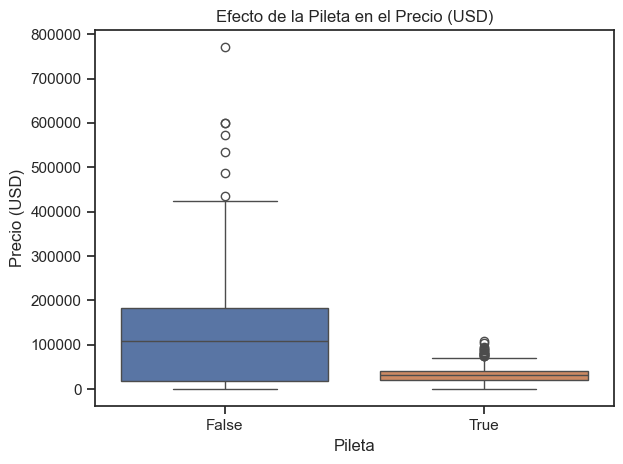

In [16]:
sns.boxplot(
    data=df,
    x='pileta',
    y='precio',
    palette='deep',
    hue='pileta',
    legend=False
)

plt.title(f'Efecto de la {LABELS['pileta']} en el {LABELS['precio']}')
plt.xlabel(f'{LABELS['pileta']}')
plt.ylabel(f'{LABELS['precio']}')
plt.tight_layout()
plt.show()

Este analisis me parecio interesante agregarlo ya que rompe compleamente con lo logico, uno se esperaria que la pileta este presente en mayor parte en las casas mas caras. Sin embargo, se ve un fenomeno raro: las casas sin pileta parecen ser mas caras que las que si tienen.

### Diferenciacion por regiones

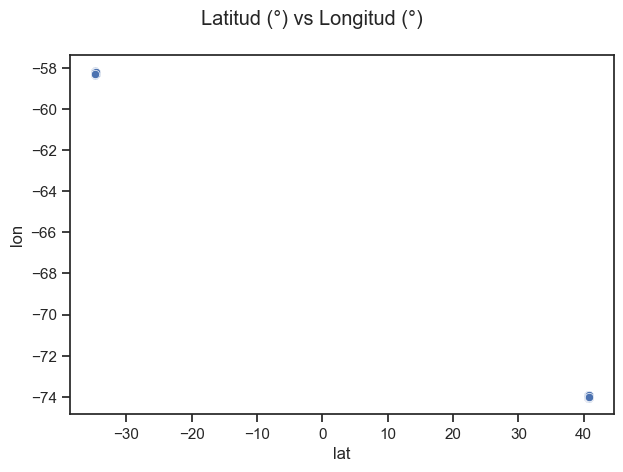

In [17]:
sns.scatterplot(
    data=df,
    x='lat',
    y='lon'
)

plt.suptitle(f'{LABELS['lat']} vs {LABELS['lon']}')
plt.tight_layout()
plt.show()

Con este ultimo grafico podemos confirmar lo que habiamos notado en el analisis general: se ven dos clusters principalmente que indican que el dataset esta dividido en dos ubicaciones distintasa (Buenos Aires y Nueva York).
Esto ya empieza a ser mas revelador, con esto podemos buscar diferencias entre ambas ciudades y eventualmente entrenar el modelo para que diferencie precios en un pais y en otro.

### Agregamos columna 'region' al dataset

In [ ]:
def splitRegion(row):
    if row['lat'] < 0: return 'Buenos Aires'
    else: return 'Nueva York'

df['region'] = df.apply(splitRegion, axis=1)
df_ba = df[df['region'] == 'Buenos Aires']
df_ny = df[df['region'] == 'Nueva York']
df.to_csv(PROCESSED_DATA_PATH + 'casas_dev.csv', index=False)

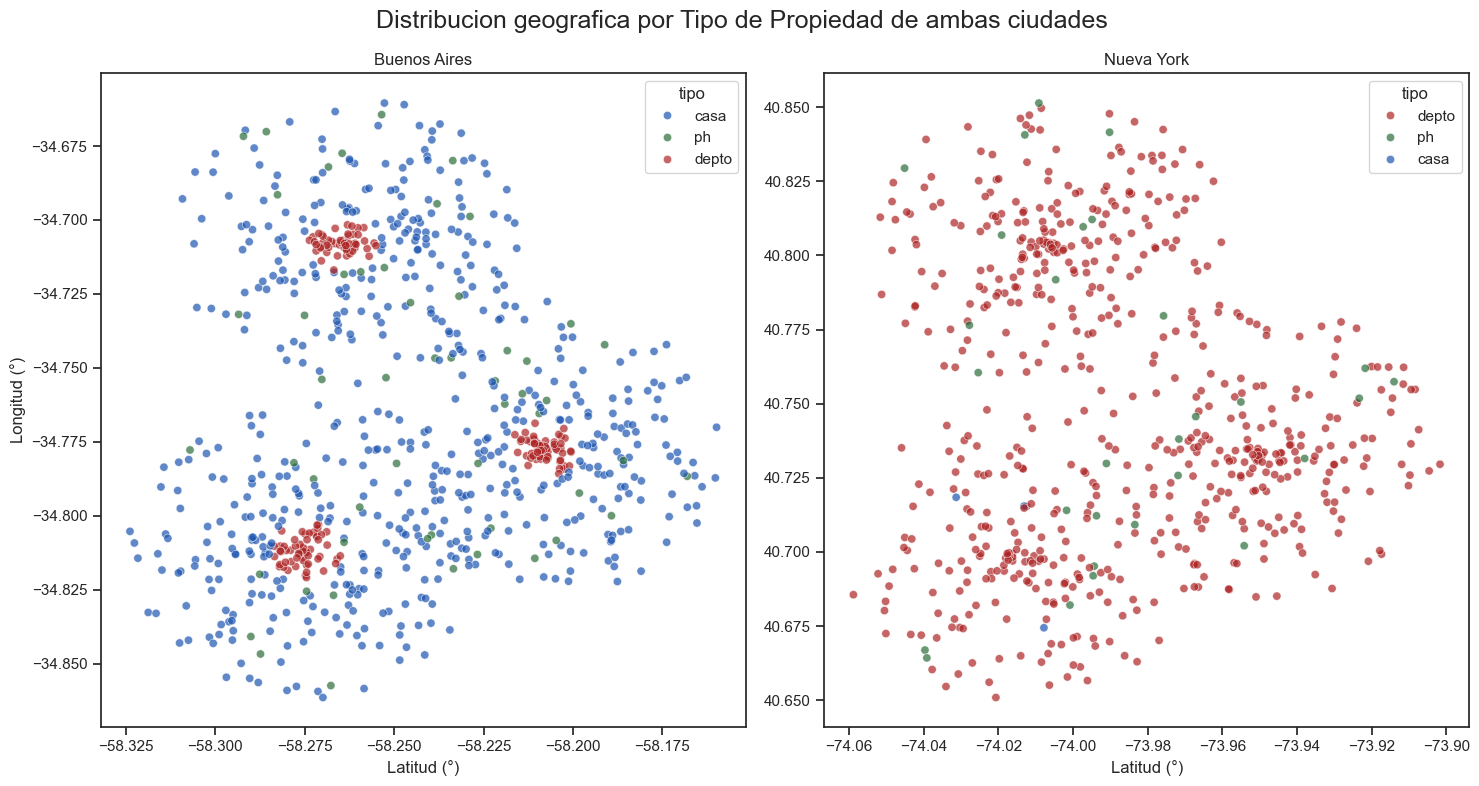

In [19]:
_, axes = plt.subplots(1, 2, figsize=(15, 8))

sns.scatterplot(
    data=df_ba,
    x='lon',
    y='lat',
    hue='tipo',
    palette=TYPES_PALETTE,
    alpha=0.7,
    ax=axes[0]
)
sns.scatterplot(
    data=df_ny,
    x='lon',
    y='lat',
    hue='tipo',
    palette=TYPES_PALETTE,
    alpha=0.7,
    ax=axes[1]
)

plt.suptitle(f'Distribucion geografica por {LABELS['tipo']} de ambas ciudades', fontsize=18)
axes[0].set_title('Buenos Aires')
axes[1].set_title('Nueva York')
axes[0].set_xlabel(LABELS['lat'])
axes[0].set_ylabel(LABELS['lon'])
axes[1].set_xlabel(LABELS['lat'])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

Ahora si vemos algo muy interesante y es que la gran mayoria de propiedades de Buenos Aires representan casi la totalidad de las casas del dataset, mientras que Nueva York se compone casi unicamente por departamentos. Otro detalle importante es la presencia de algunos departamentos en Buenos Aires que seran importantes en un momento. Por ultimo los ph se ven bastante equilibrados en ambas partes.
Con esta nueva informacion, podemos explicar mucho mejor las inconsistencias que se veian en los clusters de los graficos, gracias a la division por tipo de vivienda, los graficos de precio (tomemos edad como ejemplo), cobran muchisimo sentido.


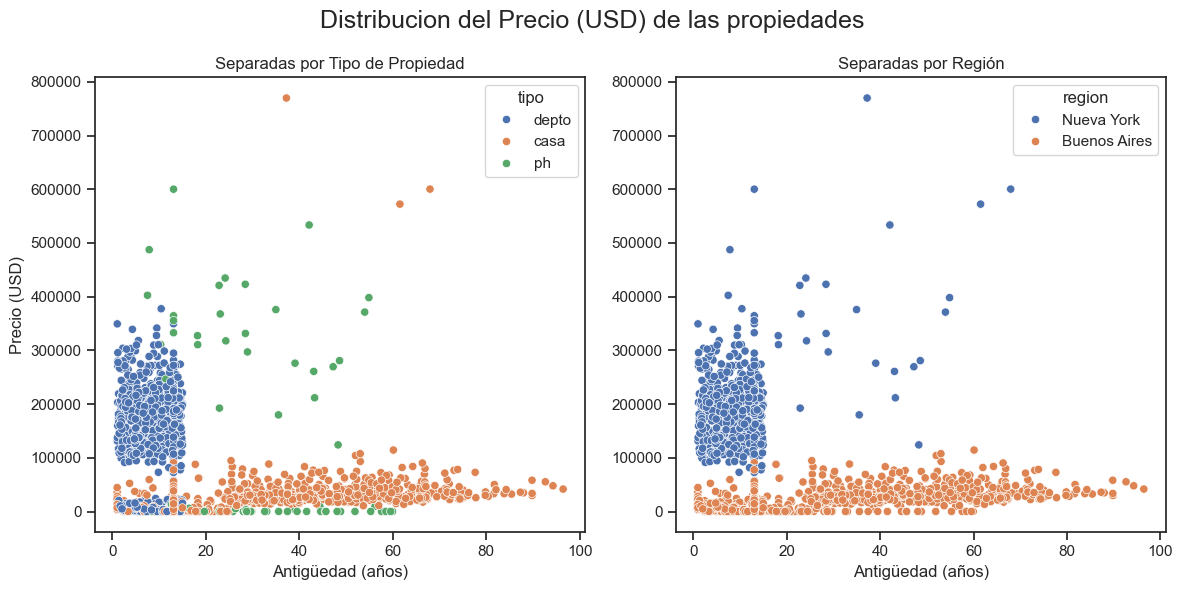

In [20]:
_, axes = plt.subplots(1, 2, figsize=(12,6))

for h, ax in zip(['tipo', 'region'], axes):
    sns.scatterplot(
        data=df,
        x='edad',
        y='precio',
        hue=h,
        ax=ax
    )

plt.suptitle(f'Distribucion del {LABELS['precio']} de las propiedades', fontsize=18)
axes[0].set_title(f'Separadas por {LABELS['tipo']}')
axes[1].set_title(f'Separadas por {LABELS['region']}')
axes[0].set_xlabel(LABELS['edad'])
axes[0].set_ylabel(LABELS['precio'])
axes[1].set_xlabel(LABELS['edad'])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

A la derecha vemos que claramente las propiedades de Buenos Aires son con diferencia mas economicas que las de Nueva York, esto nos afirma que incorporar la region como  variable categorica es un acierto. 
Como dijimos casi la totalidad de las casas son de Buenos Aires pero los unicos tres casos visibles a simple vista de Nueva York son justo las casas mas caras del set. 
La misma relacion se mantiene con los ph que estan divididos en una linea abajo del todo los de BA y dispersos por las zonas altas los de NY.
Los mas notorios, sin embargo son los departamentos, los cuales muestran que NY tiene una amplia variedad de precios mientras que los pocos de Buenos Aires estan en un muy pequeño cluster cerca del (0,0)

Ademas, ahora con esta distincion zonal se puede explicar el fenomeno de las piletas

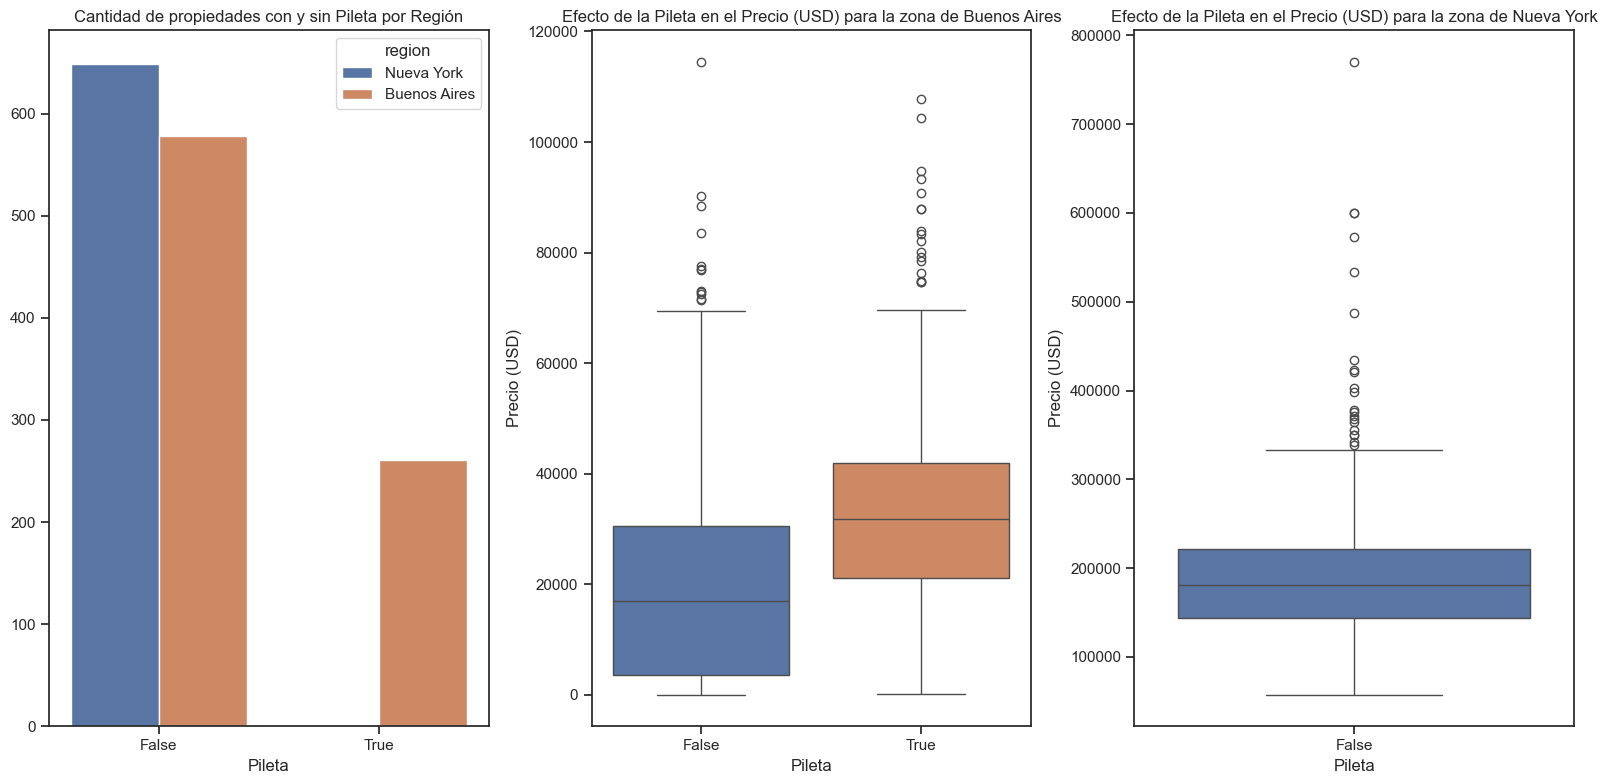

In [21]:
_, axes = plt.subplots(1, 3, figsize=(16, 8))

sns.countplot(
    data=df,
    x='pileta',
    hue='region',
    ax=axes[0]
)

axes[0].set_title(f'Cantidad de propiedades con y sin {LABELS['pileta']} por {LABELS['region']}')
axes[0].set_xlabel(f'{LABELS['pileta']}')
axes[0].set_ylabel('')

sns.boxplot(
    data=df_ba,
    x='pileta',
    y='precio',
    palette='deep',
    hue='pileta',
    legend=False,
    ax=axes[1]
)

axes[1].set_title(f'Efecto de la {LABELS['pileta']} en el {LABELS['precio']} para la zona de Buenos Aires')
axes[1].set_xlabel(f'{LABELS['pileta']}')
axes[1].set_ylabel(f'{LABELS['precio']}')

sns.boxplot(
    data=df_ny,
    x='pileta',
    y='precio',
    palette='deep',
    hue='pileta',
    legend=False,
    ax=axes[2]
)

axes[2].set_title(f'Efecto de la {LABELS['pileta']} en el {LABELS['precio']} para la zona de Nueva York')
axes[2].set_xlabel(f'{LABELS['pileta']}')
axes[2].set_ylabel(f'{LABELS['precio']}')
plt.tight_layout()
plt.show()

Ahora si se ven datos mas coherentes, en Buenos Aires se nota una tendencia por parte de la pileta en aumentar el valor de la propiedad

### Curvas de precios independientes

Ahora que tenemos esta nueva informacion, podemos analizar nuevamente las distribuciones de los precios separando por regiones para poder analizar como dos casos separados. Haciendo esto podremos entender la naturaleza de cada ciudad y ayudar a que el modelo aprenda a diferenciar una ciudad de otra y determinar que importancia le da a cada feature en base a donde esta ubicada la propiedad.

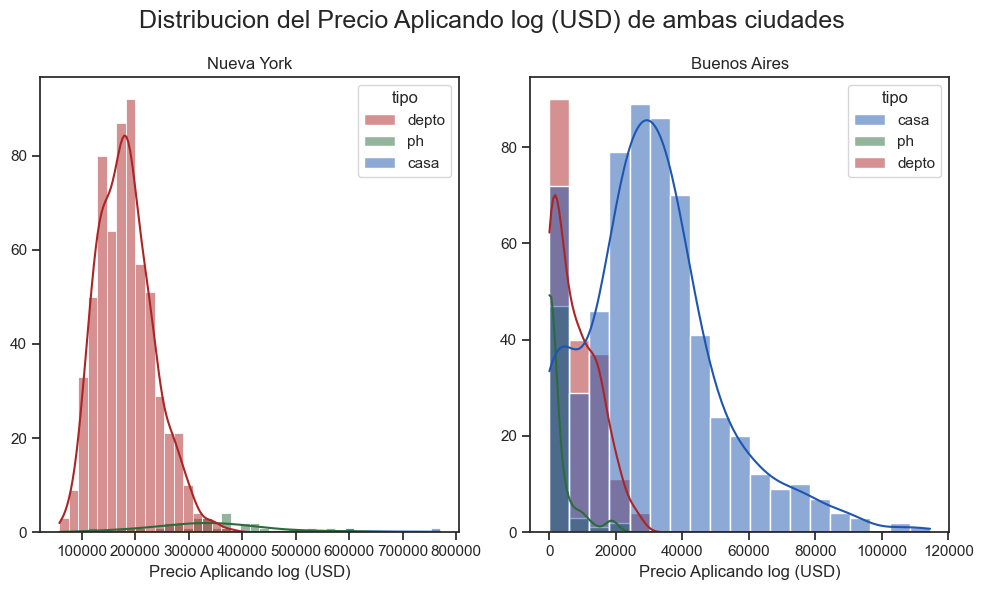

In [22]:
_, axes = plt.subplots(1, 2, figsize=(10, 6))

for reg, ax in zip(df['region'].unique(), axes):
    sns.histplot(
        data=df[df['region'] == reg],
        x='precio',
        kde=True,
        hue='tipo',
        palette=TYPES_PALETTE,
        ax=ax
    )

plt.suptitle(f'Distribucion del {LABELS['log_precio']} de ambas ciudades', fontsize=18)
axes[0].set_title('Nueva York')
axes[1].set_title('Buenos Aires')
axes[0].set_xlabel(LABELS['log_precio'])
axes[0].set_ylabel('')
axes[1].set_xlabel(LABELS['log_precio'])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

Con estos ultimos graficos ya podemos ver una tendencia mas marcada, del lado de Nueva York podemos notar una campana clarisima comparada con el grafico de los precios de Buenos Aires.
Inclusive se nota que los departamentos y ph tienen sus propias distribuciones independientes.

Viendo la de Buenos Aires podemos imaginar que muy probablemente se trate de dos campanas de Gauss combinadas, una para propiedades economicas o en alquiler y otra para propiedades con mayor valor o a la venta. Para ver mejor la distribucion aplicamos ln() a los precios suavizando las curvas y agregamos una variable que distinga los precios en BA.

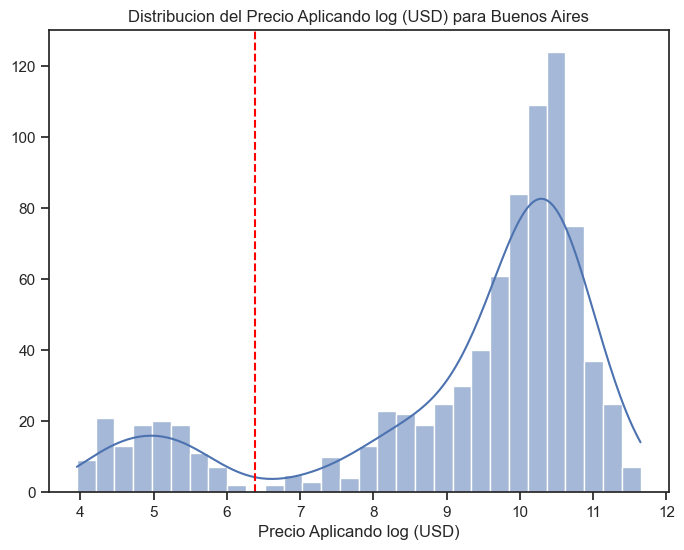

In [23]:
from utils import cutBetweenBells

fig, ax = plt.subplots(figsize=(8, 6))
df_ba = df.loc[df['region'] == 'Buenos Aires'].copy()
df_ba.loc[:, 'log_precio'] = np.log(df_ba['precio'])

logPrices = df_ba['log_precio']
cutCategory = cutBetweenBells(logPrices, [6, 7])

sns.histplot(
    data=df_ba,
    x='log_precio',
    bins=30,
    kde=True,
    ax=ax
)
    
ax.axvline(cutCategory, linestyle='--', color='red')
ax.set_title(f'Distribucion del {LABELS['log_precio']} para Buenos Aires')
ax.set_xlabel(LABELS['log_precio'])
ax.set_ylabel('')
plt.show()

Con este grafico podemos confirmar nuestra teoria, efectivamente el precio esta compuesto por dos campanas de Gauss.

# Analisis estadistico

In [24]:
from scipy import stats
from scipy.optimize import minimize

In [25]:
# target binario
# cara = 1, economica = 0

df_ba = df_ba.copy()

df_ba.loc[:, "segmento_precio"] = np.where(
    df_ba["log_precio"] < cutCategory,
    "barata",
    "cara"
)

df_ba.loc[:, "y"] = (df_ba["segmento_precio"] == "cara").astype(int)

In [26]:
df_ba.head()

,precio,tipo,area,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad,region,log_precio,segmento_precio,y
1,42435.625078,casa,229.512155,113.935741,4,1,True,-34.710794,-58.280446,67.202318,Buenos Aires,10.655744,cara,1
3,49758.465224,casa,249.165942,102.023922,5,2,False,-34.777778,-58.255182,63.200110,Buenos Aires,10.814936,cara,1
4,7256.796507,casa,170.849136,77.355172,6,2,True,-34.693175,-58.240397,4.305892,Buenos Aires,8.889694,cara,1
5,84.244291,ph,115.819630,89.400354,7,1,False,-34.787597,-58.272506,48.817601,Buenos Aires,4.433721,barata,0
7,15591.947673,casa,249.407740,156.759643,10,3,False,-34.663340,-58.266494,27.380157,Buenos Aires,9.654510,cara,1


In [27]:
df_ba = df_ba.copy()

# evitar divisiones raras
df_ba = df_ba.loc[
    (df_ba["area"] > 0) &
    (df_ba["metros_cubiertos"] > 0) &
    (df_ba["ambientes"] > 0)
].copy()

df_ba["m2_por_ambiente"] = df_ba["metros_cubiertos"] / df_ba["ambientes"]
df_ba["cobertura"] = df_ba["metros_cubiertos"] / df_ba["area"]   # que parte del lote esta construida
df_ba["area_por_ambiente"] = df_ba["area"] / df_ba["ambientes"]
df_ba["pileta_bin"] = df_ba["pileta"].astype(int)

# una medida simple de densidad/interior
df_ba["sup_libre"] = df_ba["area"] - df_ba["metros_cubiertos"]
df_ba["ratio_libre"] = df_ba["sup_libre"] / df_ba["area"]

In [28]:
def standardize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0
    return (X - mu) / sigma, mu, sigma

def kmeans_numpy(X, k=3, n_init=20, max_iter=200, random_state=42):
    rng = np.random.default_rng(random_state)
    best_labels = None
    best_centroids = None
    best_inertia = np.inf

    for _ in range(n_init):
        idx = rng.choice(len(X), size=k, replace=False)
        centroids = X[idx].copy()

        for _ in range(max_iter):
            dists = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
            labels = dists.argmin(axis=1)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
                for j in range(k)
            ])

            if np.allclose(new_centroids, centroids):
                break
            centroids = new_centroids

        inertia = ((X - centroids[labels]) ** 2).sum()

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()

    return best_labels, best_centroids, best_inertia

In [29]:
X_geo = df_ba[["lat", "lon"]].to_numpy()
X_geo_std, geo_mu, geo_sigma = standardize(X_geo)

labels_geo, centroids_geo, inertia = kmeans_numpy(X_geo_std, k=3, n_init=30)
df_ba["geo_cluster"] = labels_geo

<Axes: xlabel='lat', ylabel='lon'>

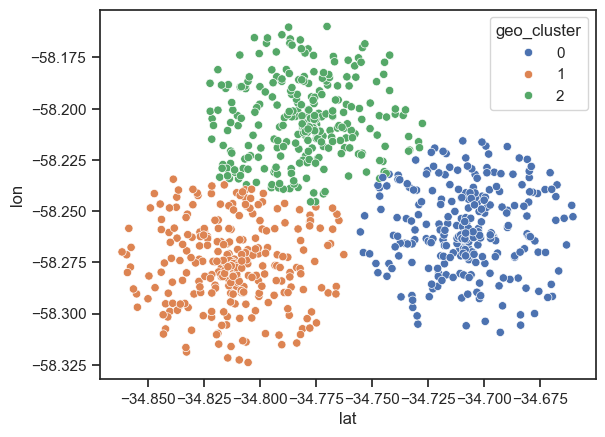

In [30]:
sns.scatterplot(
    data=df_ba,
    x='lat',
    y='lon',
    hue='geo_cluster',
    palette='deep'
)

In [31]:
def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def test_continuous(df, col, target="y"):
    g1 = df.loc[df[target] == 1, col].dropna().to_numpy()
    g0 = df.loc[df[target] == 0, col].dropna().to_numpy()

    u_stat, p_value = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    effect = rank_biserial_from_u(u_stat, len(g1), len(g0))

    return {
        "feature": col,
        "n_cara": len(g1),
        "n_economica": len(g0),
        "media_cara": g1.mean(),
        "media_economica": g0.mean(),
        "mediana_cara": np.median(g1),
        "mediana_economica": np.median(g0),
        "p_value": p_value,
        "rank_biserial": effect
    }

In [32]:
continuous_cols = [
    "area", "metros_cubiertos", "ambientes", "edad",
    "m2_por_ambiente", "cobertura", "area_por_ambiente",
    "sup_libre", "ratio_libre"
]

results_cont = pd.DataFrame([test_continuous(df_ba, c) for c in continuous_cols])
results_cont.sort_values("p_value")

,feature,n_cara,n_economica,media_cara,media_economica,mediana_cara,mediana_economica,p_value,rank_biserial
0,area,718,121,196.580332,144.105975,222.312398,131.956461,1.199233e-12,-0.403393
6,area_por_ambiente,718,121,26.521070,19.957789,24.331113,19.635586,9.392139e-12,-0.386933
7,sup_libre,718,121,73.843647,39.279431,80.254251,23.030344,2.240705e-11,-0.379774
5,cobertura,718,121,0.673777,0.795625,0.649629,0.827939,3.380146e-10,0.356546
8,ratio_libre,718,121,0.326223,0.204375,0.350371,0.172061,3.380146e-10,-0.356546
3,edad,718,121,33.732562,19.997957,31.839862,14.497553,1.583298e-09,-0.342503
1,metros_cubiertos,718,121,122.736685,104.826544,123.226868,101.731111,8.937108e-07,-0.278966
4,m2_por_ambiente,718,121,16.646536,14.975243,15.677328,14.385407,9.224241e-04,-0.188103
2,ambientes,718,121,7.912256,7.446281,9.000000,7.000000,1.020874e-02,-0.140012


In [33]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def test_categorical(df_ba, col, target="y"):
    tab = pd.crosstab(df_ba[col], df_ba[target])
    chi2, p_value, dof, expected = stats.chi2_contingency(tab)
    v = cramers_v(tab)

    return {
        "feature": col,
        "p_value": p_value,
        "cramers_v": v,
        "tabla": tab
    }

In [34]:
cat_results = []
for c in ["pileta_bin", "geo_cluster"]:
    cat_results.append(test_categorical(df_ba, c))

for r in cat_results:
    print("\nFEATURE:", r["feature"])
    print("p_value:", r["p_value"])
    print("cramers_v:", r["cramers_v"])
    print(r["tabla"])


FEATURE: pileta_bin
p_value: 0.0006115912593514244
cramers_v: 0.1182931956045187
y             0    1
pileta_bin          
0           100  478
1            21  240

FEATURE: geo_cluster
p_value: 1.4766376477074247e-19
cramers_v: 0.32149586726103824
y             0    1
geo_cluster         
0            23  250
1            85  197
2            13  271


In [35]:
def benjamini_hochberg(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    adjusted = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adjusted[i] = prev

    out = np.empty(n)
    out[order] = adjusted
    return out

In [36]:
results_cont["p_adj"] = benjamini_hochberg(results_cont["p_value"].values)
results_cont.sort_values("p_adj")

,feature,n_cara,n_economica,media_cara,media_economica,mediana_cara,mediana_economica,p_value,rank_biserial,p_adj
0,area,718,121,196.580332,144.105975,222.312398,131.956461,1.199233e-12,-0.403393,1.079309e-11
6,area_por_ambiente,718,121,26.521070,19.957789,24.331113,19.635586,9.392139e-12,-0.386933,4.226463e-11
7,sup_libre,718,121,73.843647,39.279431,80.254251,23.030344,2.240705e-11,-0.379774,6.722115e-11
5,cobertura,718,121,0.673777,0.795625,0.649629,0.827939,3.380146e-10,0.356546,6.084262e-10
8,ratio_libre,718,121,0.326223,0.204375,0.350371,0.172061,3.380146e-10,-0.356546,6.084262e-10
3,edad,718,121,33.732562,19.997957,31.839862,14.497553,1.583298e-09,-0.342503,2.374947e-09
1,metros_cubiertos,718,121,122.736685,104.826544,123.226868,101.731111,8.937108e-07,-0.278966,1.149057e-06
4,m2_por_ambiente,718,121,16.646536,14.975243,15.677328,14.385407,9.224241e-04,-0.188103,1.037727e-03
2,ambientes,718,121,7.912256,7.446281,9.000000,7.000000,1.020874e-02,-0.140012,1.020874e-02


In [37]:
def bootstrap_diff_median(x1, x0, n_boot=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    diffs = []

    for _ in range(n_boot):
        s1 = rng.choice(x1, size=len(x1), replace=True)
        s0 = rng.choice(x0, size=len(x0), replace=True)
        diffs.append(np.median(s1) - np.median(s0))

    diffs = np.array(diffs)
    ci_low = np.percentile(diffs, 2.5)
    ci_high = np.percentile(diffs, 97.5)

    return diffs.mean(), ci_low, ci_high

In [38]:
for col in ["metros_cubiertos", "area", "edad", "m2_por_ambiente"]:
    x1 = df_ba.loc[df_ba["y"] == 1, col].dropna().to_numpy()
    x0 = df_ba.loc[df_ba["y"] == 0, col].dropna().to_numpy()

    mean_diff, ci_low, ci_high = bootstrap_diff_median(x1, x0)
    print(f"{col}: diff_mediana = {mean_diff:.3f}, IC95% = [{ci_low:.3f}, {ci_high:.3f}]")

metros_cubiertos: diff_mediana = 21.732, IC95% = [13.799, 31.160]
area: diff_mediana = 90.467, IC95% = [77.015, 103.606]
edad: diff_mediana = 17.260, IC95% = [12.760, 20.856]
m2_por_ambiente: diff_mediana = 1.288, IC95% = [0.409, 2.599]


In [39]:
df_model = df_ba.copy()

geo_dummies = pd.get_dummies(df_model["geo_cluster"], prefix="geo", drop_first=True)
df_model = pd.concat([df_model, geo_dummies], axis=1)

feature_cols = [
    "area", "metros_cubiertos", "ambientes", "edad",
    "pileta_bin", "m2_por_ambiente", "cobertura",
    "area_por_ambiente", "ratio_libre"
] + list(geo_dummies.columns)

X = df_model[feature_cols].copy()
y = df_model["y"].to_numpy()

In [40]:
def fit_standardizer(X_df):
    mu = X_df.mean(axis=0)
    sigma = X_df.std(axis=0, ddof=0).replace(0, 1)
    return mu, sigma

def transform_standardizer(X_df, mu, sigma):
    return (X_df - mu) / sigma

In [41]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_logistic_regression(X, y, l2=1.0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_design = np.column_stack([np.ones(len(X)), X])

    def loss_fn(w):
        z = X_design @ w
        p = sigmoid(z)
        eps = 1e-12
        loss = -(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)).mean()
        reg = l2 * np.sum(w[1:] ** 2) / len(y)
        return loss + reg

    def grad_fn(w):
        z = X_design @ w
        p = sigmoid(z)
        grad = (X_design.T @ (p - y)) / len(y)
        grad[1:] += 2 * l2 * w[1:] / len(y)
        return grad

    w0 = np.zeros(X_design.shape[1])
    res = minimize(loss_fn, w0, jac=grad_fn, method="L-BFGS-B")
    return res.x

def predict_proba_logistic(X, w):
    X = np.asarray(X, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    return sigmoid(X_design @ w)

In [42]:
def auc_score(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]

    n_pos = len(pos)
    n_neg = len(neg)

    if n_pos == 0 or n_neg == 0:
        return np.nan

    comparisons = (pos[:, None] > neg[None, :]).sum()
    ties = (pos[:, None] == neg[None, :]).sum()

    auc = (comparisons + 0.5 * ties) / (n_pos * n_neg)
    return auc

In [43]:
def stratified_kfold_indices(y, k=5, random_state=42):
    rng = np.random.default_rng(random_state)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    folds_pos = np.array_split(idx_pos, k)
    folds_neg = np.array_split(idx_neg, k)

    folds = []
    all_idx = np.arange(len(y))

    for i in range(k):
        test_idx = np.concatenate([folds_pos[i], folds_neg[i]])
        train_mask = np.ones(len(y), dtype=bool)
        train_mask[test_idx] = False
        train_idx = all_idx[train_mask]
        folds.append((train_idx, test_idx))

    return folds

In [44]:
def cross_validate_logistic(X_df, y, k=5, l2=1.0, random_state=42):
    folds = stratified_kfold_indices(y, k=k, random_state=random_state)
    aucs = []

    for train_idx, test_idx in folds:
        X_train = X_df.iloc[train_idx].copy()
        X_test = X_df.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        mu, sigma = fit_standardizer(X_train)
        X_train_std = transform_standardizer(X_train, mu, sigma).to_numpy()
        X_test_std = transform_standardizer(X_test, mu, sigma).to_numpy()

        w = fit_logistic_regression(X_train_std, y_train, l2=l2)
        proba = predict_proba_logistic(X_test_std, w)
        auc = auc_score(y_test, proba)
        aucs.append(auc)

    return np.array(aucs)

In [45]:
aucs = cross_validate_logistic(X, y, k=5, l2=1.0, random_state=42)
print("AUC por fold:", aucs)
print("AUC media:", aucs.mean())
print("AUC std:", aucs.std())

AUC por fold: [0.81833333 0.79918981 0.76851852 0.86363636 0.86043124]
AUC media: 0.8220218531468533
AUC std: 0.03634435884676287


In [46]:
def permutation_test_auc(X_df, y, n_perm=300, k=5, l2=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    observed = cross_validate_logistic(X_df, y, k=k, l2=l2, random_state=random_state).mean()

    perm_aucs = []
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        auc_perm = cross_validate_logistic(
            X_df, y_perm, k=k, l2=l2, random_state=random_state + i + 1
        ).mean()
        perm_aucs.append(auc_perm)

    perm_aucs = np.array(perm_aucs)
    p_value = (np.sum(perm_aucs >= observed) + 1) / (n_perm + 1)

    return observed, perm_aucs, p_value

In [47]:
observed_auc, perm_aucs, p_perm = permutation_test_auc(X, y, n_perm=200, k=5, l2=1.0)
print("AUC observada:", observed_auc)
print("p-value permutacional:", p_perm)

AUC observada: 0.8220218531468533
p-value permutacional: 0.004975124378109453


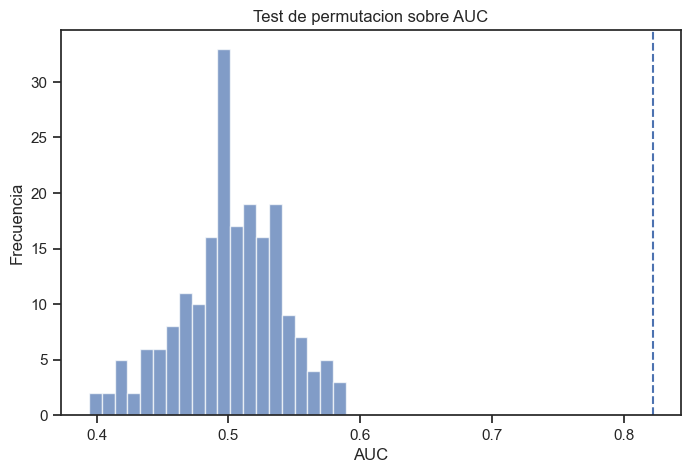

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(perm_aucs, bins=20, alpha=0.7)
plt.axvline(observed_auc, linestyle="--")
plt.title("Test de permutacion sobre AUC")
plt.xlabel("AUC")
plt.ylabel("Frecuencia")
plt.show()